# TD11: Linguistic laws

## 0. Question

Today, we will answer the following questions:

- Does the Brown corpus follow the rank-frequency pattern predicted by Zipf's law?
- Are frequent words in the Brown corpus shorter on average than less frequent words (Zipf's law of abbreviation)?

We will use the Brown corpus from NLTK -- a classic balanced corpus of written English. 

In [1]:
import nltk # corpus access
import numpy as np # numerical computation
import pandas as pd # data-frame manipulation
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
from nltk.corpus import brown # Brown corpus
from scipy.optimize import curve_fit # fitting the curve
from sklearn.metrics import r2_score # coefficient of determination

sns.set(context='paper', style='ticks',
        font_scale=1, palette='colorblind')

If the Brown corpus is not installed in your environment yet, run the following cell:

In [2]:
try:
    brown.ensure_loaded()
except LookupError:
    nltk.download('brown')
    brown.ensure_loaded()

## 1. Data

### 1.1. Loading the Brown corpus

Let's start by loading all word tokens from the Brown corpus.

In [3]:
tokens = brown.words()
len(tokens)

1161192

What do the first tokens look like?

In [4]:
tokens[:40]

['The',
 'Fulton',
 'County',
 'Grand',
 'Jury',
 'said',
 'Friday',
 'an',
 'investigation',
 'of',
 "Atlanta's",
 'recent',
 'primary',
 'election',
 'produced',
 '``',
 'no',
 'evidence',
 "''",
 'that',
 'any',
 'irregularities',
 'took',
 'place',
 '.',
 'The',
 'jury',
 'further',
 'said',
 'in',
 'term-end',
 'presentments',
 'that',
 'the',
 'City',
 'Executive',
 'Committee',
 ',',
 'which',
 'had']

### 1.2. Cleaning the corpus

For this practical, we will only keep alphabetic tokens and we will lowercase everything. This removes punctuation and makes frequencies easier to interpret. 

Convert tokens to lowercase and keep only alphabetic tokens.

In [10]:
words = [i.lower() for i in tokens if i.isalpha()]

Let's inspect the cleaned tokens.

In [11]:
words[:40]

['the',
 'fulton',
 'county',
 'grand',
 'jury',
 'said',
 'friday',
 'an',
 'investigation',
 'of',
 'recent',
 'primary',
 'election',
 'produced',
 'no',
 'evidence',
 'that',
 'any',
 'irregularities',
 'took',
 'place',
 'the',
 'jury',
 'further',
 'said',
 'in',
 'presentments',
 'that',
 'the',
 'city',
 'executive',
 'committee',
 'which',
 'had',
 'charge',
 'of',
 'the',
 'election',
 'deserves',
 'the']

How many cleaned word tokens and unique words do we have?

In [14]:
len(words), len(set(words))

(981716, 40234)

### 1.3. Building a frequency table

Now we will count how often each word type occurs in the corpus.

In [15]:
freq_table = (
    pd.Series(words, name='word')
      .value_counts()
      .rename_axis('word')
      .reset_index(name='frequency')
)

freq_table.head(10)

,word,frequency
0,the,69971
1,of,36412
2,and,28853
3,to,26158
4,a,23195
5,in,21337
6,that,10594
7,is,10109
8,was,9815
9,he,9548


Let's add the rank of each word and its length in letters. Name the columns `rank` and `length` respectively. How can you add the rank? Can you use the `index` of the DataFrame?

In [16]:
freq_table['length'] = freq_table['word'].str.len()
freq_table['rank'] = freq_table.index + 1

In [17]:
freq_table.head(10)

,word,frequency,length,rank
0,the,69971,3,1
1,of,36412,2,2
2,and,28853,3,3
3,to,26158,2,4
4,a,23195,1,5
5,in,21337,2,6
6,that,10594,4,7
7,is,10109,2,8
8,was,9815,3,9
9,he,9548,2,10


## 2. Zipf's law

### 2.1. A first look at the rank-frequency distribution

We first plot the rank and frequency of a 100 most frequent words on the original scale:

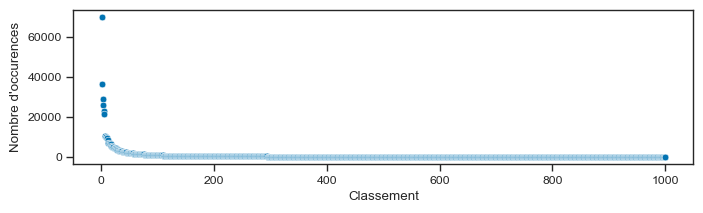

In [24]:
plt.figure(figsize=(8, 2))
sns.scatterplot(data=freq_table.head(1000), 
                x='rank', y='frequency')
plt.xlabel('Classement')
plt.ylabel("Nombre d'occurences")
plt.show()

The decay is easier to see on log-log axes. Modify your initial plot to use log-log axes. Use the plt.xscale and plt.yscale functions to set the axes to logarithmic scale.

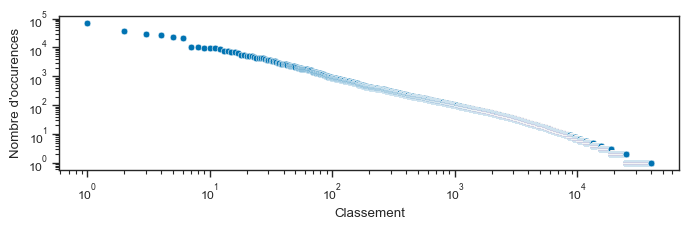

In [28]:
plt.figure(figsize=(8, 2))
sns.scatterplot(data=freq_table, 
                x='rank', y='frequency')
plt.xlabel('Classement')
plt.ylabel("Nombre d'occurences")
plt.xscale('log')
plt.yscale('log')
plt.show()

### 2.2. Checking rank x frequency

A simple rule-of-thumb version of Zipf's law says that `rank x frequency` should be roughly stable for a large part of the distribution.

In [ ]:
zipf_check = freq_table.head(1000).copy()
zipf_check['rank_x_frequency'] = zipf_check['rank'] * zipf_check['frequency']

zipf_check[['rank', 'frequency', 'rank_x_frequency']].head(10)

,rank,frequency,rank_x_frequency
0,1,69971,69971
1,2,36412,72824
2,3,28853,86559
3,4,26158,104632
4,5,23195,115975
5,6,21337,128022
6,7,10594,74158
7,8,10109,80872
8,9,9815,88335
9,10,9548,95480


Let's summarize this quantity.

In [30]:
zipf_check['rank_x_frequency'].describe()

count      1000.000000
mean      95652.183000
std        5816.101146
min       69971.000000
25%       91271.250000
50%       96131.000000
75%      100502.500000
max      128022.000000
Name: rank_x_frequency, dtype: float64

And now let's plot it. You need to plot rank times frequency against rank. What do you see? Is it stable? 

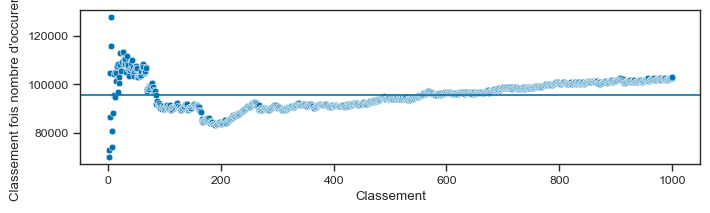

In [33]:
plt.figure(figsize=(8, 2))
sns.scatterplot(data=zipf_check, 
                x='rank', y='rank_x_frequency')
plt.xlabel('Classement')
plt.ylabel("Classement fois nombre d'occurences")
plt.axhline(y=zipf_check['rank_x_frequency'].mean())
plt.show()

(array([  3.,   1.,  63., 325., 298., 266.,  38.,   5.,   0.,   1.]),
 array([ 69971. ,  75776.1,  81581.2,  87386.3,  93191.4,  98996.5,
        104801.6, 110606.7, 116411.8, 122216.9, 128022. ]),
 <BarContainer object of 10 artists>)

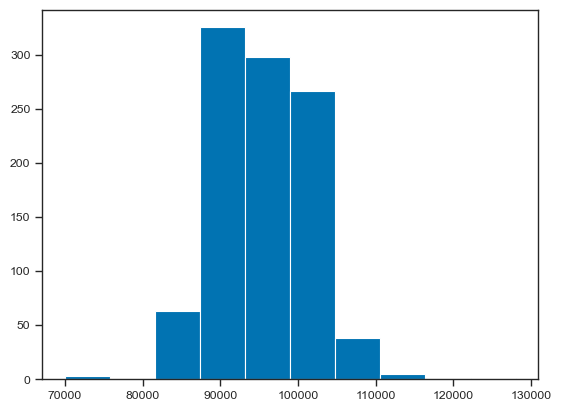

In [34]:
plt.hist(zipf_check['rank_x_frequency'])

### 2.3. Fitting Zipf's law

To keep the fit readable, we will focus on the 2000 most frequent words. We first fit the basic power-law model

$$f(r) = A / r^b$$

In [45]:
fit_data = freq_table.copy()

ranks = fit_data['rank'].to_numpy(dtype=float)
frequencies = fit_data['frequency'].to_numpy(dtype=float)

Frequencies are stored as counts, let's convert them to relative frequencies by dividing by the total number of tokens. Store them in the `relative_frequencies` variable.

In [46]:
relative_frequencies = frequencies / len(words)

Now let's define the original Zipf's law:

In [47]:
def zipf_basic(r, A, b):
    return A / (r ** b)

Let's fit the original Zipf's law:

In [48]:
params, _ = curve_fit(
    zipf_basic,
    ranks,
    relative_frequencies,
    bounds=(0, np.inf),
    maxfev=10000
)

A_basic, b_basic = params
basic_prediction = zipf_basic(ranks, A_basic, b_basic)

# keep these for the next cell
log_ranks = np.log(ranks)
log_frequencies = np.log(frequencies)

print(f"Basic model: f(r) = {A_basic:.1f} / r^{b_basic:.2f}")

Basic model: f(r) = 0.1 / r^0.89


Let's now plot the preidctions:

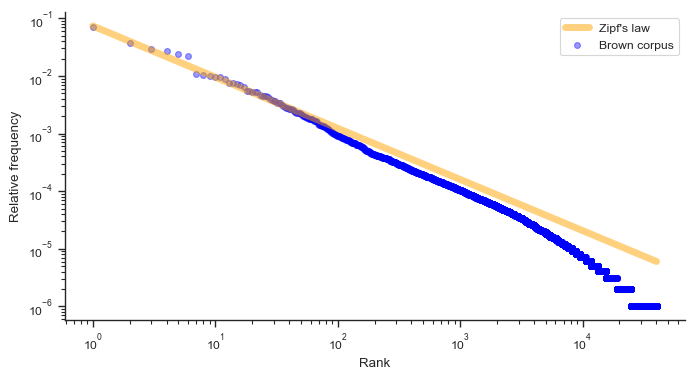

In [49]:
plt.figure(figsize=(8, 4))

# fitted curve
plt.plot(ranks, basic_prediction, 
         label="Zipf's law", color='orange',
         linewidth=5, alpha=0.5)

# observed points as scatter
plt.scatter(ranks, relative_frequencies, 
            alpha=0.4, s=18, label='Brown corpus',
            color='blue')

# apply symlog scales after plotting
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Rank')
plt.ylabel('Relative frequency')
sns.despine()
plt.legend()
plt.show()

Now let's compute the coefficient of determination $R^2$ for the original Zipf's law:

In [50]:
r2_basic = r2_score(relative_frequencies, basic_prediction)
print(f"R² (basic Zipf model): {r2_basic:.4f}")

R² (basic Zipf model): 0.9847


Now let's try the Zipf-Mandelbrot law, which adds two parameters to the original Zipf's law:

$$f(r) = A / (r + c)^b$$

Repeat the fitting and plotting steps for the Zipf-Mandelbrot law, based on what we did above. 

In [ ]:
def zipf_mandelbrot(r, A, b, c):
    return A / (r + c) ** b


params, _ = curve_fit(
    zipf_mandelbrot,
    ranks,
    relative_frequencies,
    bounds=(0, np.inf),
    maxfev=1000000
)

A_zm, b_zm, c_zm = params
basic_prediction = zipf_mandelbrot(r=ranks, A=A_zm, b=b_zm, c=c_zm)

print(f"Zipf-Mandelbrot model: f(r) = {A_zm:.1f} / (r + {c_zm:.2f})^{b_zm:.2f}")

Zipf-Mandelbrot model: f(r) = 0.1 / (r + 0.53)^1.00


Now let's plot the Zipf-Mandelbrot predictions:

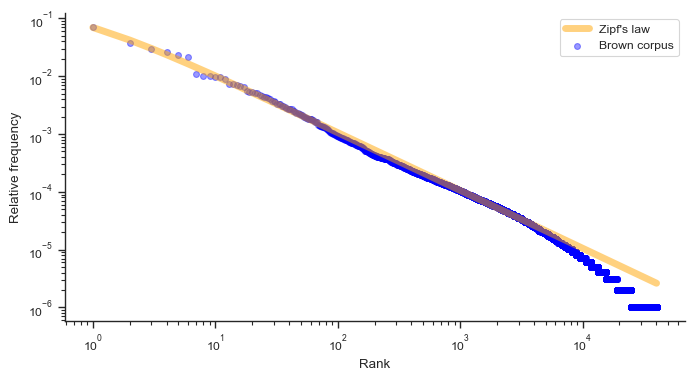

In [53]:
plt.figure(figsize=(8, 4))

# fitted curve
plt.plot(ranks, basic_prediction, 
         label="Zipf's law", color='orange',
         linewidth=5, alpha=0.5)

# observed points as scatter
plt.scatter(ranks, relative_frequencies, 
            alpha=0.4, s=18, label='Brown corpus',
            color='blue')

# apply symlog scales after plotting
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Rank')
plt.ylabel('Relative frequency')
sns.despine()
plt.legend()
plt.show()

Let's compute the $R^2$ for the Zipf-Mandelbrot law:

In [54]:
r2_basic = r2_score(relative_frequencies, basic_prediction)
print(f"R² (basic Zipf model): {r2_basic:.4f}")

R² (basic Zipf model): 0.9896


Which model fits better? Why do you think that is?

## 3. Zipf's law of abbreviation

### 3.1. Preparing the data

For this part, we will use the same frequency table, but we will focus on words that occur at least 5 times. This makes the pattern less noisy.

In [56]:
abbreviation_data = freq_table.query('frequency >= 5').copy()
abbreviation_data.shape

(13366, 4)

Let's inspect the beginning of this table.

In [58]:
abbreviation_data[['word', 'frequency', 'length']].head(10)
abbreviation_data['relative_frequency'] = abbreviation_data['frequency'] / len(words)

In [59]:
abbreviation_data

,word,frequency,length,rank,relative_frequency
0,the,69971,3,1,0.071274
1,of,36412,2,2,0.037090
2,and,28853,3,3,0.029390
3,to,26158,2,4,0.026645
4,a,23195,1,5,0.023627
...,...,...,...,...,...
13361,academically,5,12,13362,0.000005
13362,justifiably,5,11,13363,0.000005
13363,locality,5,8,13364,0.000005
13364,archaic,5,7,13365,0.000005


### 3.2. Visual inspection

We can now plot word length against frequency. Since frequency is very skewed, we will use a logarithmic x-axis.

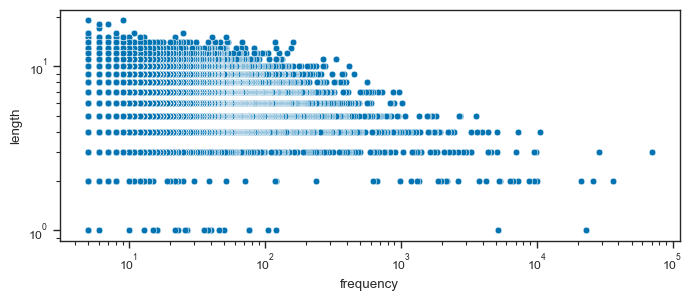

In [62]:
plt.figure(figsize=(8, 3))
sns.scatterplot(data=abbreviation_data, x='frequency', y='length')
plt.xscale('log')
plt.yscale('log')

### 3.3. A permutation test

A simple way to test the Zipf's law of abbreviation is to compare the observed value of

$$\sum_i \text{length}_i \times \text{frequency}_i$$

against a null distribution where word lengths are randomly reassigned to frequencies.

In [64]:
lengths = abbreviation_data['length'].to_numpy(dtype=float)
frequencies = abbreviation_data['relative_frequency'].to_numpy(dtype=float)

observed = np.sum(lengths * frequencies)
observed

4.306654877785428

Let's build the null distribution by shuffling the lengths 2000 times. You would need to build an array of 2000 values of the above sum, where in each iteration you shuffle the lengths and compute the sum again. Use np.random.permutation to shuffle the lengths.

In [66]:
np.random.seed(42)
null_statistics = np.empty(2000)

for i in range(len(null_statistics)):
    random_lengths = np.random.permutation(lengths)
    random_frequencies = np.random.permutation(frequencies)

    null_statistics[i] = np.sum(random_frequencies * random_lengths)

What is the mean and standard deviation of the null distribution? Is it bigger or smaller than the observed value? What does it mean?

In [69]:
print(null_statistics.mean(), null_statistics.std())

6.917921834318682 0.2444442498705777


Finally, let's visualize the null distribution against the observed value.

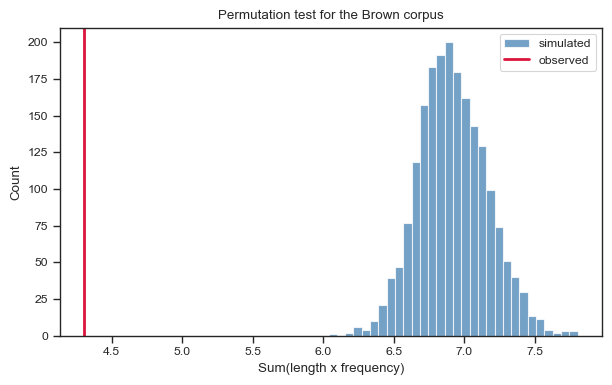

In [68]:
plt.figure(figsize=(7, 4))
plt.hist(null_statistics, bins=30, alpha=0.75, color='steelblue',
         label='simulated')
plt.axvline(observed, color='crimson', linewidth=2, label='observed')
plt.xlabel('Sum(length x frequency)')
plt.ylabel('Count')
plt.title('Permutation test for the Brown corpus')
plt.legend()
plt.show()